In [1]:
# Colab Setup (Run this first)

In [2]:
!pip install litebird_sim rich

zsh:1: command not found: pip


To run this notebook, you have several options:

-   If you are running this under Binder, you should already be set!
-   If you are running this under Google Colab, be sure to run the cell with `!pip install…` that is right above the title.
-   If you are running this locally, you should first create and activate a new virtual environment with the commands

    ```
    python -m venv ./my_venv
    source ./my_venv/bin/activate
    ```

    (you can use Conda environments, if you prefer) and install Jupyter and litebird_sim in it:

    ```
    pip install jupyter litebird_sim
    ```

    If you have a local copy of the `litebird_sim` repository cloned from <https://github.com/litebird/litebird_sim> (e.g., because you're part of the Simulation Team!), you can use a _development install_ instead:

    ```
    cd /my/local/copy/litebird_sim
    pip install -e .
    ```


## Import Modules

In [3]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

import litebird_sim as lbs

from litebird_sim.coordinates import CoordinateSystem

## Define Parameters

In [4]:
start_time = 0
time_span_s = 365*24*3600
nside = 512
imo_location = "schema.json"
imo = lbs.Imo(flatfile_location=lbs.PTEP_IMO_LOCATION)
imo_version = "vPTEP"

## Create Simulation

In [5]:
sim = lbs.Simulation(
    start_time=start_time, duration_s=time_span_s, random_seed=0, imo=imo
)

comm = sim.mpi_comm

[2026-07-13 17:20:44,944 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 17:20:44,944 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


## Define Frequency Channel

In [6]:
telescope = "MFT"
channel = "M2-119"

channelinfo = lbs.FreqChannelInfo.from_imo(
    url=f"/releases/{imo_version}/satellite/{telescope}/{channel}/channel_info",
    imo=imo,
)

## Define Scanning Strategy

In [7]:
sim.set_scanning_strategy(
    imo_url=f"/releases/{imo_version}/satellite/scanning_parameters/",
)

## Define Instrument

In [8]:
instrument_info = lbs.InstrumentInfo.from_imo(
    imo,
    url=f"/releases/{imo_version}/satellite/{telescope}/instrument_info",
)

sim.set_instrument(instrument_info)

hwp_radpsec = instrument_info.hwp_rpm * 2 * np.pi / 60

## Set HWP

In [9]:
# if Mueller formalism
#
# sim.set_hwp(
#    lbs.NonIdealHWP(hwp_radpsec, harmonic_expansion=True, calculus=lbs.HWPFormalism.MUELLER)
# )

# if Jones formalism
sim.set_hwp(
    lbs.NonIdealHWP(
        hwp_radpsec, harmonic_expansion=True, calculus=lbs.HWPFormalism.MUELLER
    )
)

## Define Detectors

In [10]:
det = lbs.DetectorInfo.from_imo(
    url=f"/releases/{imo_version}/satellite/{telescope}/{channel}/{channelinfo.detector_names[0]}/detector_info",
    imo=imo,
)

# This is usually not needed. PTEP IMo has no pointing_theta_phi_psi_deg value, so we're setting some values in here so that the code does not break.
det.pointing_theta_phi_psi_deg = [0,0,0]
det.pol_angle_rad=0
# We're also reducing the sampling rate so that the simulation goes faster.
det.sampling_rate_hz = 1

# if Mueller
det.mueller_hwp = {
    "0f": np.array([[1, 0, 0], [0, 0, 0], [0, 0, 0]], dtype=np.float64),
    "2f": np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]], dtype=np.float64),
    "4f": np.array(
        [
            [0, 0, 0],
            [3.9e-5, 1, 1],
            [3.9e-5, 1, 1],
        ],
        dtype=np.float64,
    ),
}

mueller_phases = {
    "2f": np.array(
        [[-2.32, -0.49, -2.06], [2.86, -0.25, -2.00], [1.29, -2.01, 2.54]],
        dtype=np.float64,
    ),
    "4f": np.array(
        [
            [0, 0, 0],
            [0.14, -0.00061, -0.00056 - np.pi / 2],
            [-1.43, -0.00070 - np.pi / 2, np.pi - 0.00065],
        ],
        dtype=np.float64,
    ),
}

mueller_phases = {
    "2f": np.zeros((3, 3)),
    "4f": np.array(
        [
            [0, 0, 0],
            [0, 0, -np.pi / 2],
            [0, -np.pi / 2, np.pi],
        ],
        dtype=np.float64,
    ),
}


# if Jones
#det.jones_hwp = {
#    "0f": np.array([[1, 0], [0, -1]], dtype=np.complex128,
#    ),
#    "2f": np.array(
#        [
#            [
#                9.67e-01 * np.exp(1j * np.deg2rad(5.51e01)),
#                6.16e-02 * np.exp(1j * np.deg2rad(1.26e02)),
#            ],
#            [
#                6.18e-02 * np.exp(1j * np.deg2rad(1.25e02)),
#                9.85e-01 * np.exp(1j * np.deg2rad(-1.46e02)),
#            ],
#        ],
#        dtype=np.complex128,),
#}


In [11]:
det.pol_angle_rad

0

## Create Observations and Prepare Pointings

In [12]:
(obs,) = sim.create_observations(
    detectors=[det],
)

sim.prepare_pointings(append_to_report=False)
sim.precompute_pointings()

## Generate Input Sky Maps

In [13]:
sky_params = lbs.SkyGenerationParams(
    make_cmb=True,
    make_dipole=True,
    make_fg=True,
    fg_models=["s1", "d1"],
    seed_cmb=1,  # set this seed if you want to fix the CMB realization
    apply_beam=True,  # if True, smooths the input map by the beam of the channel
    bandpass_integration=False,  # if True, integrates over the top-hat bandpass of the channel
    units="K_CMB",
    output_type="map",
    nside=nside,
)

sky = sim.get_sky(
    parameters=sky_params,
    channels=channelinfo,
)

[2026-07-13 17:20:47,410 INFO MPI#0000] Generating CMB...
[2026-07-13 17:20:47,662 INFO MPI#0000] Generating Foregrounds...
[2026-07-13 17:20:47,663 INFO MPI#0000] Retrieve data for pysm_2/synch_t_new.fits (if not cached already)
[2026-07-13 17:20:47,664 INFO MPI#0000] NSIDE = 512
[2026-07-13 17:20:47,664 INFO MPI#0000] ORDERING = RING in fits file
[2026-07-13 17:20:47,664 INFO MPI#0000] INDXSCHM = IMPLICIT
[2026-07-13 17:20:47,803 INFO MPI#0000] Retrieve data for pysm_2/synch_q_new.fits (if not cached already)
[2026-07-13 17:20:47,804 INFO MPI#0000] NSIDE = 512
[2026-07-13 17:20:47,805 INFO MPI#0000] ORDERING = RING in fits file
[2026-07-13 17:20:47,805 INFO MPI#0000] INDXSCHM = IMPLICIT
[2026-07-13 17:20:47,943 INFO MPI#0000] Retrieve data for pysm_2/synch_u_new.fits (if not cached already)
[2026-07-13 17:20:47,944 INFO MPI#0000] NSIDE = 512
[2026-07-13 17:20:47,945 INFO MPI#0000] ORDERING = RING in fits file
[2026-07-13 17:20:47,945 INFO MPI#0000] INDXSCHM = IMPLICIT
[2026-07-13 17:

## Generate HwpSys object and Set its parameters

## Fill TOD and perform Mapmaking on-the-fly

In [14]:
lbs.scan_map_in_observations(
    observations=[obs],
    maps=sky,
    mueller_phases=mueller_phases
)

(3, 3145728)


[2026-07-13 17:20:54,379 INFO MPI#0000] Sigma is 0.000000 arcmin (0.000000 rad) 
[2026-07-13 17:20:54,379 INFO MPI#0000] -> fwhm is 0.000000 arcmin
[2026-07-13 17:20:57,547 INFO MPI#0000] Sigma is 0.000000 arcmin (0.000000 rad) 
[2026-07-13 17:20:57,547 INFO MPI#0000] -> fwhm is 0.000000 arcmin
[2026-07-13 17:21:00,650 INFO MPI#0000] Sigma is 0.000000 arcmin (0.000000 rad) 
[2026-07-13 17:21:00,650 INFO MPI#0000] -> fwhm is 0.000000 arcmin


(3, 3145728)


In [15]:
output_maps = sim.make_binned_map(nside=nside,output_coordinate_system=CoordinateSystem.Ecliptic).binned_map

## Show Output Maps

[2026-07-13 17:23:27,950 INFO MPI#0000] Sigma is 0.000000 arcmin (0.000000 rad) 
[2026-07-13 17:23:27,951 INFO MPI#0000] -> fwhm is 0.000000 arcmin
[2026-07-13 17:23:31,033 INFO MPI#0000] Sigma is 0.000000 arcmin (0.000000 rad) 
[2026-07-13 17:23:31,033 INFO MPI#0000] -> fwhm is 0.000000 arcmin
[2026-07-13 17:23:34,122 INFO MPI#0000] Sigma is 0.000000 arcmin (0.000000 rad) 
[2026-07-13 17:23:34,123 INFO MPI#0000] -> fwhm is 0.000000 arcmin


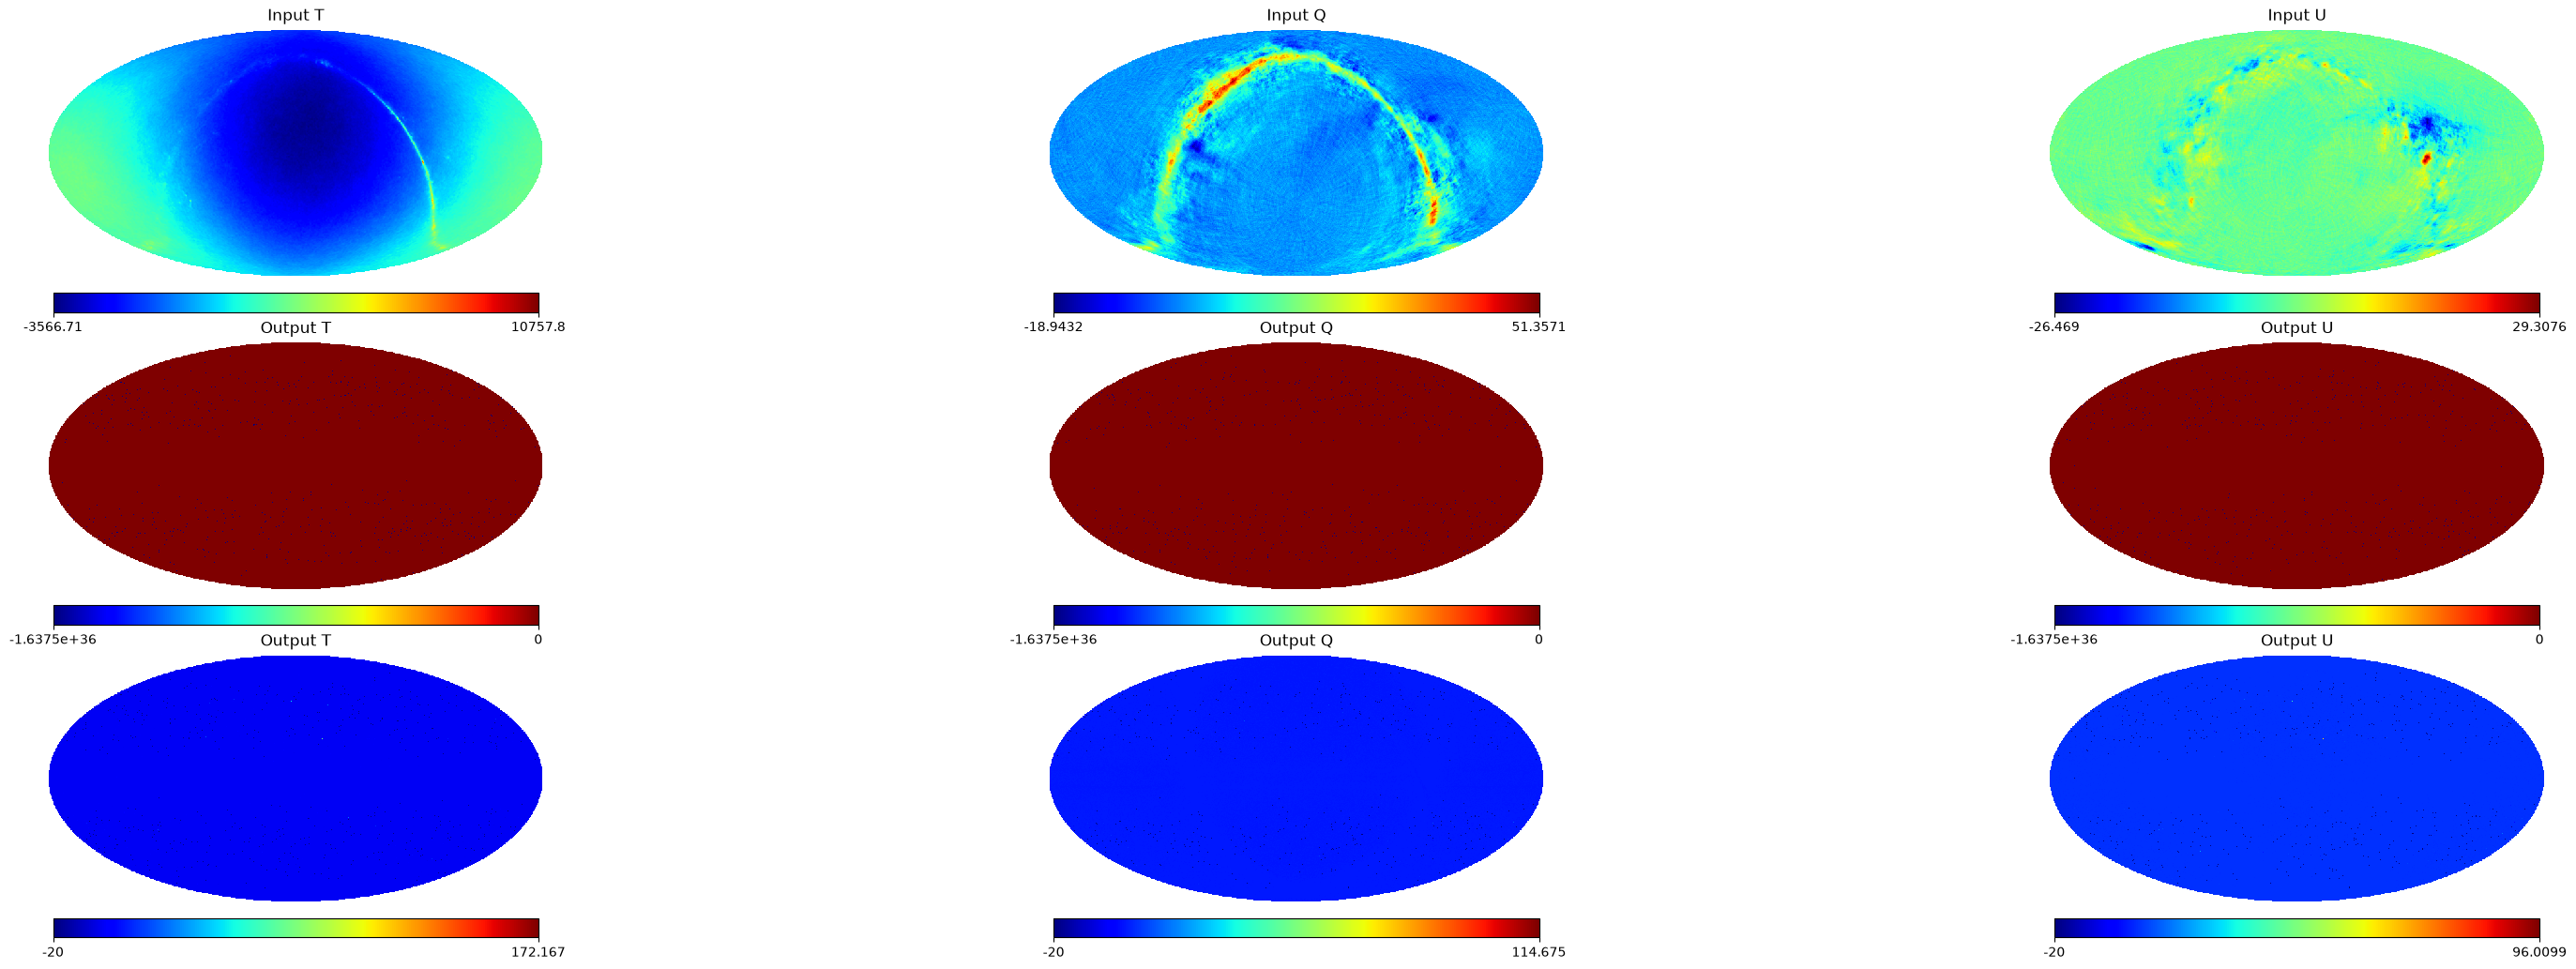

In [17]:
# the input skies are rotated to ecliptic inside lbs.hwp_harmonics module
# so we rotate them in here as well before plotting
input_maps=sky["M2-119"].values
r = hp.Rotator(coord=['G','E'])
input_maps=np.array([r.rotate_map_alms(m) for m in input_maps])

plt.figure(figsize=(32, 10))
stokes_parameters = ["T", "Q", "U"]
diff=output_maps-input_maps
for i in range(3):
    hp.mollview(
        input_maps[i]*1e6,
        cmap="jet",
        sub=(3, 3, i + 1),
        title="Input " + stokes_parameters[i],
    )
    hp.mollview(
        output_maps[i]*1e6,
        cmap="jet",
        sub=(3, 3, i + 4),
        title="Output " + stokes_parameters[i],
    )
    hp.mollview(
        diff[i]*1e6,
        min=-20,
        cmap="jet",
        sub=(3, 3, i + 7),
        title="Output " + stokes_parameters[i],
    )